<a href="https://colab.research.google.com/github/rmilde/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%205/assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [4]:
import pandas as pd
import numpy as np
import wbgapi as wb
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score)
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [6]:
# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

#Drop countries missing >40% of indicators
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators missing >40% of countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Median-impute remaining gaps.
country_data = country_data.fillna(country_data.median())

In [7]:
y_continuous = country_data[OUTCOME_VAR]

# Binary crisis indicator: 1 if growth < 0, else 0
country_data['crisis'] = (country_data[OUTCOME_VAR] < 0).astype(int)

In [8]:

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test



In [9]:
n_countries, n_vars = country_data.shape
print(f"Dataset dimensions: {n_countries} countries and {n_vars} variables")

crisis_counts = country_data['crisis'].value_counts()

n_crisis = crisis_counts.get(1, 0)
n_no_crisis = crisis_counts.get(0, 0)

print(f"\nCrisis countries (crisis = 1): {n_crisis}")
print(f"Non-crisis countries (cirsis = 0): {n_no_crisis}")

base_rate = country_data['crisis'].mean()
print(f"\nCrisis base rate: {base_rate:}")

Dataset dimensions: 238 countries and 30 variables

Crisis countries (crisis = 1): 38
Non-crisis countries (cirsis = 0): 200

Crisis base rate: 0.15966386554621848


In [10]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

In [11]:
r2_train = model.score(X_train_scaled, y_train)
r2_test  = model.score(X_test_scaled, y_test)

print(f"Training R²: {r2_train:}")
print(f"Test R²:     {r2_test:}")

r2_gap = r2_train - r2_test
print(f"R-Squared gap (train - test): {r2_gap:}")

p = X_train.shape[1]
n = X_train.shape[0]

print(f"p/n ratio (training set): {p}/{n} = {p/n:.3f}")

Training R²: 0.6800391488084908
Test R²:     -0.112988805936167
R-Squared gap (train - test): 0.7930279547446578
p/n ratio (training set): 29/166 = 0.175


A high p/n ratio causes OLS to overfit. OLS starts fitting the noise rather than the true signal causing  high variance which is evident in the R squared.

In [12]:
alphas = np.logspace(-4, 4, 100)

# Ridge here
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# Predict
y_train_pred_ridge = ridge_cv.predict(X_train_scaled)
y_test_pred_ridge  = ridge_cv.predict(X_test_scaled)

# Lasso here
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

# Predict
y_train_pred_lasso = lasso_cv.predict(X_train_scaled)
y_test_pred_lasso  = lasso_cv.predict(X_test_scaled)

In [47]:
ridge_r2_train = ridge_cv.score(X_train_scaled, y_train)
ridge_r2_test  = ridge_cv.score(X_test_scaled, y_test)
ridge_nonzero  = np.sum(ridge_cv.coef_ != 0)

print("Ridge:")
print(f"λ* (alpha): {ridge_cv.alpha_:.2f}")
print(f"Non-zero coefficients: {ridge_nonzero}")
print(f"Train R-Squared: {ridge_r2_train:.2f}")
print(f"Test R-Squared:  {ridge_r2_test:.2f}")

Ridge:
λ* (alpha): 54.62
Non-zero coefficients: 29
Train R-Squared: 0.65
Test R-Squared:  0.36


In [48]:
lasso_r2_train = lasso_cv.score(X_train_scaled, y_train)
lasso_r2_test  = lasso_cv.score(X_test_scaled, y_test)
lasso_nonzero  = np.sum(lasso_cv.coef_ != 0)

print("\nLasso:")
print(f"λ* (alpha): {lasso_cv.alpha_:.2f}")
print(f"Non-zero coefficients: {lasso_nonzero}")
print(f"Train R-Squared: {lasso_r2_train:.2f}")
print(f"Test R-Squared:  {lasso_r2_test:.2f}")


Lasso:
λ* (alpha): 0.10
Non-zero coefficients: 16
Train R-Squared: 0.64
Test R-Squared:  0.38


In [49]:
from sklearn.metrics import mean_squared_error

ols_train_r2 = model.score(X_train_scaled, y_train)
ols_test_r2  = model.score(X_test_scaled, y_test)
ols_test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled)))

ridge_train_r2 = ridge_cv.score(X_train_scaled, y_train)
ridge_test_r2  = ridge_cv.score(X_test_scaled, y_test)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_cv.predict(X_test_scaled)))

lasso_train_r2 = lasso_cv.score(X_train_scaled, y_train)
lasso_test_r2  = lasso_cv.score(X_test_scaled, y_test)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_cv.predict(X_test_scaled)))

# Non-zero coefficients
ols_nonzero = len(model.coef_)
ridge_nonzero = np.sum(ridge_cv.coef_ != 0)
lasso_nonzero = np.sum(lasso_cv.coef_ != 0)


results = pd.DataFrame({
    "λ* (alpha)": [np.nan, ridge_cv.alpha_, lasso_cv.alpha_],
    "Non-zero Predictors": [ols_nonzero, ridge_nonzero, lasso_nonzero],
    "Training R-Squared": [ols_train_r2, ridge_train_r2, lasso_train_r2],
    "Test R-Squared": [ols_test_r2, ridge_test_r2, lasso_test_r2],
    "Test RMSE": [ols_test_rmse, ridge_test_rmse, lasso_test_rmse]
}, index=["OLS", "Ridge", "Lasso"])

results

,λ* (alpha),Non-zero Predictors,Training R-Squared,Test R-Squared,Test RMSE
OLS,NaN,29,0.680039,-0.112989,2.228664
Ridge,54.622772,29,0.645687,0.362346,1.686910
Lasso,0.097701,16,0.638792,0.379680,1.663823


I would recommend Lasso to the IMF Director for operational GDP growth forecasting. While both Lasso and Ridge has more bias than OLS, they have less variance reducing teh difference between teh training and testing R squared. And Lasso uses less predictors than Ridge so it is easier to justify and tell a story with.

In [16]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled,
    y_train,
    alphas=np.logspace(-4, 2, 100)
)

In [17]:
alpha_star = lasso_cv.alpha_

# coefficients at λ*
coef_at_star = lasso_cv.coef_

# which variables are non-zero at λ*
active = coef_at_star != 0

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_15716/3401001583.py:16: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Lasso Coefficient Paths (Highlighted at $\lambda^*$)')


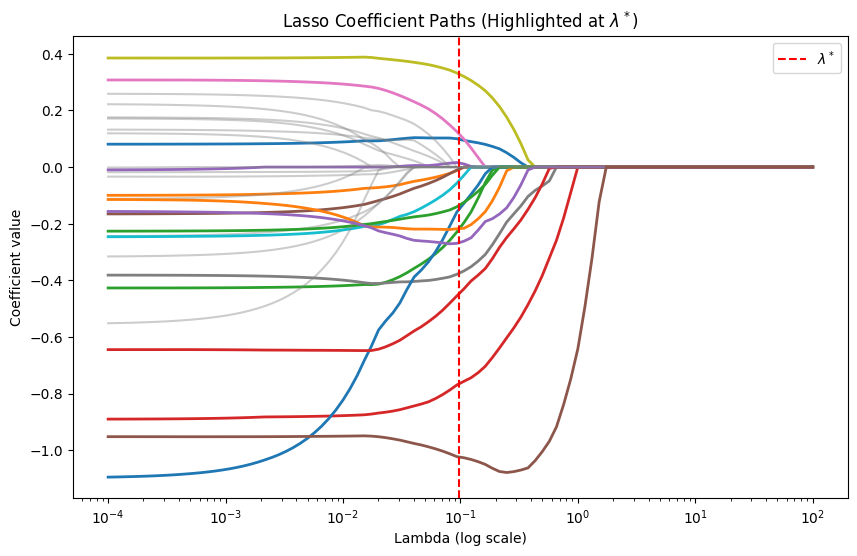

In [18]:
plt.figure(figsize=(10, 6))

# plot paths
for i in range(coefs_path.shape[0]):
    if active[i]:
        plt.plot(alphas_path, coefs_path[i, :], linewidth=2)  # highlighted
    else:
        plt.plot(alphas_path, coefs_path[i, :], color='gray', alpha=0.4)  # muted

# vertical line
plt.axvline(alpha_star, linestyle='--', color='red', label=r'$\lambda^*$')

plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Coefficient Paths (Highlighted at $\lambda^*$)')
plt.legend()
plt.show()


Written Response: This interoperation is wrong because it fundamentally misinterprets what Lasso does. It just means that life_expectancy has conditional predictive redundancy so it doesn't add untying new that another variable in the model doesn't already add. Lasso looks at the correlation structure of the variables to decide what to keep and what not to keep.


In [19]:
selected_features = np.array(feature_names)[lasso_cv.coef_ != 0]
X_selected = country_data[selected_features]

# train and test split
X_train_sel, X_test_sel, y_train_cls, y_test_cls = train_test_split(
    X_selected,
    country_data['crisis'].values,
    test_size=0.30,
    random_state=42
)

# stanardizing again
scaler_lpm = StandardScaler()
X_train_sel_scaled = scaler_lpm.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_lpm.transform(X_test_sel)

In [20]:
lpm = LinearRegression()
lpm.fit(X_train_sel_scaled, y_train_cls)

# predict
y_train_pred_lpm = lpm.predict(X_train_sel_scaled)
y_test_pred_lpm = lpm.predict(X_test_sel_scaled)

In [21]:
below_0 = np.sum(y_test_pred_lpm < 0)
above_1 = np.sum(y_test_pred_lpm > 1)

print(f"Predictions < 0: {below_0}")
print(f"Predictions > 1: {above_1}")

Predictions < 0: 34
Predictions > 1: 9


Predicted probabilities outside [0,1] are a fundamental problem because they make no sense in the real world. You can't have a negative probability of something, let alone of a crisis. That means something is very wrong with the model if that appears.



In [22]:
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_sel_scaled, y_train_cls)

# Predictt
y_train_pred_logit = logit.predict(X_train_sel_scaled)
y_test_pred_logit  = logit.predict(X_test_sel_scaled)


y_test_prob_logit = logit.predict_proba(X_test_sel_scaled)[:, 1]

In [23]:
print(f"Intercept: {logit.intercept_[0]:.2f}")

coef_series = pd.Series(logit.coef_[0], index=selected_features)

print("Coefficients:")
print(coef_series)

Intercept: -3.92
Coefficients:
arable_land_pct                  -0.322315
royalties_receipts               -0.130722
atms_per100k                      0.047379
inflation_cpi                     0.196316
real_interest_rate                0.019461
govt_expenditure_pct_gdp         -0.018292
mobile_subscriptions_per100       0.056752
natural_resource_rents_pct_gdp    0.230947
exchange_rate_official            0.035742
tertiary_enrollment_gross        -0.012146
infant_mortality_per1000          0.067384
health_expenditure_pct_gdp        0.149032
unemployment_rate                 0.220486
population_growth                 0.219785
urbanization_pct                  0.182730
crisis                            2.642336
dtype: float64


In [25]:
coef_series = pd.Series(logit.coef_[0], index=selected_features)

odds_ratios = np.exp(coef_series)

# create table
table = pd.DataFrame({
    "Coefficient": coef_series,
    "Odds Ratio": odds_ratios})

table["Abs Distance from 1"] = np.abs(table["Odds Ratio"] - 1)
table = table.sort_values(by="Abs Distance from 1", ascending=False)

table = table.drop(columns=["Abs Distance from 1"])

table

,Coefficient,Odds Ratio
crisis,2.642336,14.045980
arable_land_pct,-0.322315,0.724470
natural_resource_rents_pct_gdp,0.230947,1.259792
unemployment_rate,0.220486,1.246683
population_growth,0.219785,1.245808
inflation_cpi,0.196316,1.216912
urbanization_pct,0.182730,1.200491
health_expenditure_pct_gdp,0.149032,1.160710
royalties_receipts,-0.130722,0.877462
infant_mortality_per1000,0.067384,1.069706


In [26]:
y_test_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

# Min and max
print(f"Min predicted probability: {y_test_prob.min():.2f}")
print(f"Max predicted probability: {y_test_prob.max():.2f}")

Min predicted probability: 0.00
Max predicted probability: 0.99


One standard deviation increase in natural resource rents as a percentage of GDP multiples the odds of crisis by 1.26 holding all else constant.

In [27]:
strongest_var = table.index[0]
idx = list(selected_features).index(strongest_var)

# Grid over that feature (in standardized space)
x_vals = np.linspace(X_train_sel_scaled[:, idx].min(),
                     X_train_sel_scaled[:, idx].max(), 200)

# Build design matrix: all zeros except this feature
X_grid = np.zeros((len(x_vals), X_train_sel_scaled.shape[1]))
X_grid[:, idx] = x_vals

# Predictions
lpm_curve = lpm.predict(X_grid)
logit_curve = logit.predict_proba(X_grid)[:, 1]

x_actual = X_test_sel_scaled[:, idx]
y_actual = y_test_cls

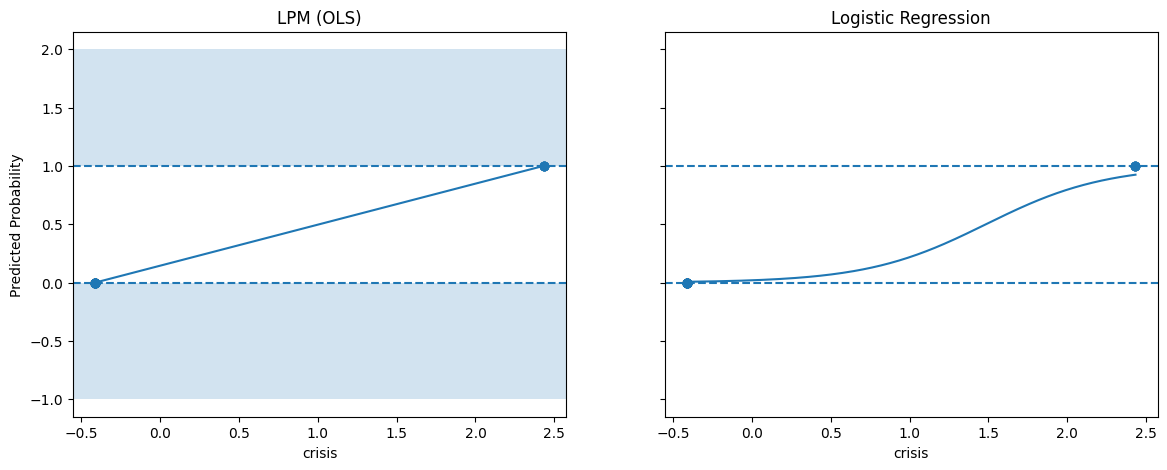

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(x_actual, y_actual, alpha=0.4)
axes[0].plot(x_vals, lpm_curve)

# Shade invalid regions
axes[0].axhspan(-1, 0, alpha=0.2)   # P < 0
axes[0].axhspan(1, 2, alpha=0.2)    # P > 1

# Reference lines
axes[0].axhline(0, linestyle='--')
axes[0].axhline(1, linestyle='--')

axes[0].set_title("LPM (OLS)")
axes[0].set_xlabel(strongest_var)
axes[0].set_ylabel("Predicted Probability")

axes[1].scatter(x_actual, y_actual, alpha=0.4)
axes[1].plot(x_vals, logit_curve)

# Reference lines
axes[1].axhline(0, linestyle='--')
axes[1].axhline(1, linestyle='--')

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel(strongest_var)

plt.show()

In [30]:
base_rate = np.mean(y_test_cls)
print(f"Crisis base rate: {base_rate:.2f}")

y_naive = np.zeros_like(y_test_cls)

# compute accuracy
naive_accuracy = np.mean(y_naive == y_test_cls)

# compute recall
naive_recall = np.sum((y_naive == 1) & (y_test_cls == 1)) / np.sum(y_test_cls == 1)

print("Naive baseline:")
print(f"Accuracy: {naive_accuracy:.2f}")
print(f"Recall: {naive_recall:.2f}")

Crisis base rate: 0.19
Naive baseline:
Accuracy: 0.81
Recall: 0.00


In [31]:
y_pred_logit = (y_test_prob >= 0.5).astype(int)

# compute accuracy
logit_accuracy = np.mean(y_pred_logit == y_test_cls)

# compute recall
logit_recall = np.sum((y_pred_logit == 1) & (y_test_cls == 1)) / np.sum(y_test_cls == 1)

print("Logistic Regression (τ = 0.5):")
print(f"Accuracy: {logit_accuracy:.2f}")
print(f"Recall: {logit_recall:.2f}")

Logistic Regression (τ = 0.5):
Accuracy: 1.00
Recall: 1.00


If I reported only accurate to the Division Chief, they would be misled because accuracy works better for the group of countries that have never have a crisis so on the countries that do have a crisis which is the group we care about most is being missed and not evaluated well.

In [32]:
y_pred_logit = (y_test_prob >= 0.5).astype(int)

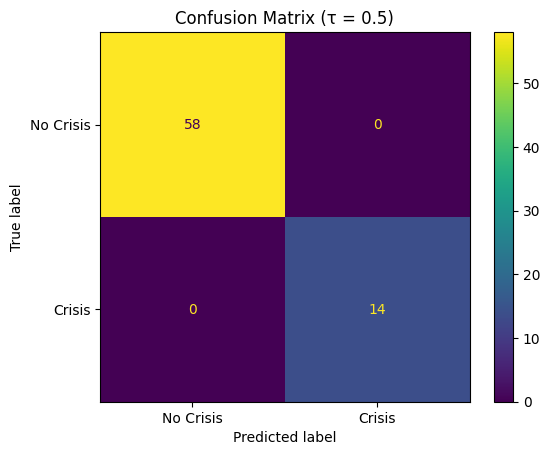

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test_cls, y_pred_logit)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Crisis', 'Crisis'])
disp.plot()
plt.title("Confusion Matrix (τ = 0.5)")
plt.show()

In [35]:
print("Classification Report (τ = 0.5):\n")
print(classification_report(y_test_cls, y_pred_logit))

Classification Report (τ = 0.5):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        14

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



In [36]:
TN, FP, FN, TP = cm.ravel()

print("\nKey Outcomes:")
print(f"True Positives (crises correctly flagged): {TP}")
print(f"False Negatives (crises missed): {FN}")
print(f"False Positives (false alarms): {FP}")
print(f"True Negatives: {TN}")


Key Outcomes:
True Positives (crises correctly flagged): 14
False Negatives (crises missed): 0
False Positives (false alarms): 0
True Negatives: 58


A false negative is more costly because that would mean a crisis happened and the IMF missed it so they couldn't help which hurts people more than thinking a crisis is going to happen and the crisis doesn't actually happen because the crisis doesn't actually happen. Therefore the Division Chief should prioritize Recall which is the model;'s ability to actually catch the true cases of crisis.

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# ROC
fpr, tpr, _ = roc_curve(y_test_cls, y_test_prob)
roc_auc = roc_auc_score(y_test_cls, y_test_prob)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test_cls, y_test_prob)
pr_auc = average_precision_score(y_test_cls, y_test_prob)

# baseline (crisis rate)
base_rate = np.mean(y_test_cls)

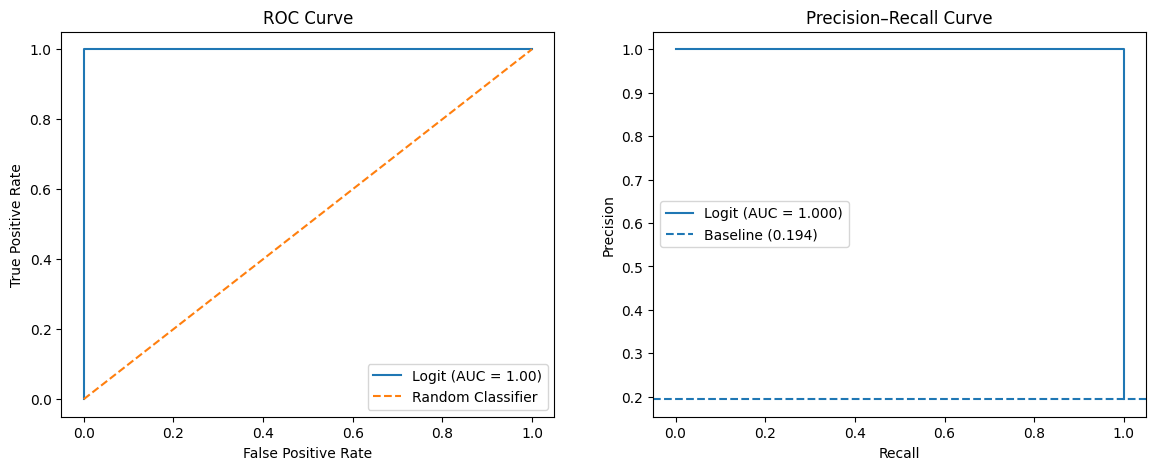

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"Logit (AUC = {roc_auc:.2f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall, precision, label=f"Logit (AUC = {pr_auc:.3f})")

axes[1].axhline(base_rate, linestyle="--", label=f"Baseline ({base_rate:.3f})")

axes[1].set_title("Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.show()

The ROC-AUC curve is higher than the PR=AUC curve because the ROC-AUC benefits form teh abundance of true negatives while PR=AUC ignores them entirely. That is harder because there are less of those cases. For the IMF crisis detection mission the PR-ACU curve is more informative because when a criss happens, flagging it correctly and not missing it is the most important thing.




In [40]:
thresholds = np.arange(0.01, 1.00, 0.01)

n_flags = []
precisions = []
recalls = []
f1s = []

for tau in thresholds:
    y_pred = (y_test_prob >= tau).astype(int)

    tp = np.sum((y_pred == 1) & (y_test_cls == 1))
    fp = np.sum((y_pred == 1) & (y_test_cls == 0))
    fn = np.sum((y_pred == 0) & (y_test_cls == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    n_flags.append(np.sum(y_pred))
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)

In [41]:
n_flags = np.array(n_flags)

valid_idx = np.where(n_flags <= 5)[0]

cap_idx = valid_idx[0]
tau_cap = thresholds[cap_idx]

y_cap = (y_test_prob >= tau_cap).astype(int)

tp = np.sum((y_cap == 1) & (y_test_cls == 1))
fp = np.sum((y_cap == 1) & (y_test_cls == 0))
fn = np.sum((y_cap == 0) & (y_test_cls == 1))

cap_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
cap_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print("Capacity-Constrained Threshold:")
print(f"tau = {tau_cap:.2f}")
print(f"Flags = {n_flags[cap_idx]}")
print(f"precision = {cap_precision:.2f}")
print(f"Recall = {cap_recall:.2f}")

Capacity-Constrained Threshold:
tau = 0.97
Flags = 5
precision = 1.00
Recall = 0.36


In [42]:
f1s = np.array(f1s)

best_idx = np.argmax(f1s)
tau_f1 = thresholds[best_idx]

print("F1 Optimal Threshold:")
print(f"tau = {tau_f1:.2f}")
print(f"F1 = {f1s[best_idx]:.2f}")
print(f"Flags = {n_flags[best_idx]}")

F1 Optimal Threshold:
tau = 0.12
F1 = 1.00
Flags = 14


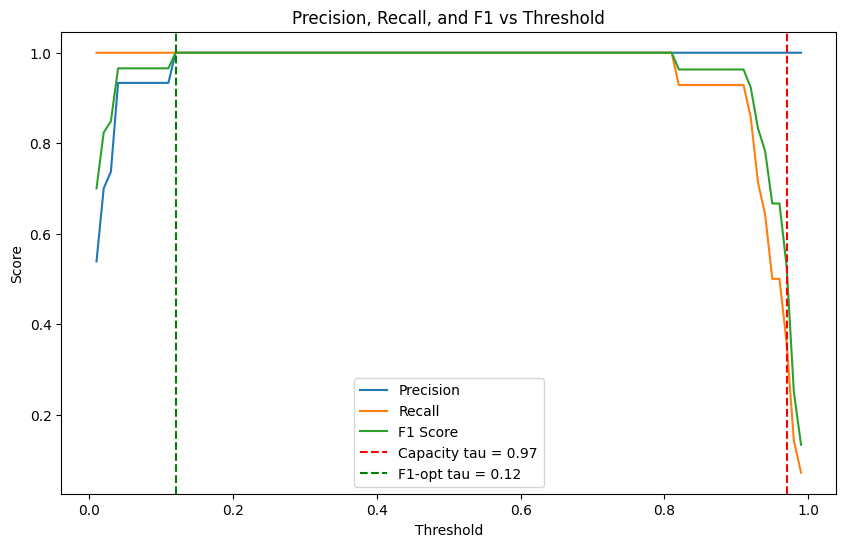

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1 Score")

plt.axvline(tau_cap, linestyle="--", color="red", label=f"Capacity tau = {tau_cap:.2f}")
plt.axvline(tau_f1, linestyle="--", color="green", label=f"F1-opt tau = {tau_f1:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Threshold")
plt.legend()
plt.show()

The IMF should adopt a threshold of 0.12, because that that threshold the recall is the best it can be which is most important to us. However, this does come with the tradeoff of having more false positives which can be costly and annoying. However, this tradeoff is worth it.

PRIME PROMPT:

Prep: Act as an expert Python Data Scientist. The daatset you are working with has macroeconomics indicators (standardized) for many countires and is being used for cirsis prediciton. I already made a training dataset X_train_scaled and the outcome y_train_clas that is binary.

Request: So far in my code I have plotted a single Lasso Path. But with correlated WDI predictors, the path is sensitive to which countries are in the sample — two correlated indicators can exchange roles across bootstrap resamples. Wite complete python code that draws 200 bootstrap resamples (with replacement) from the training data.
Fits LassoCV on each resample and records the selected features.
Computes the selection frequency for each predictor: the fraction of bootstrap samples in which Lasso assigns it a non-zero coefficient.
Produces a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 50%.

Iterate: The script must use cross fold validation and computes the selection frequency for each predictor: the fraction of bootstrap samples in which Lasso assigns it a non-zero coefficient.
It also must produces a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 50%.

Mechanism Check: Add inline comments explaining everything exactly and uses a fixed random seed for reporducability.

Evaluate:  Provide a breif explanation of how I should interpt the output and which predictors are “stable” (selected >80% of the time) and which are “fragile” (selected < 30 %)?

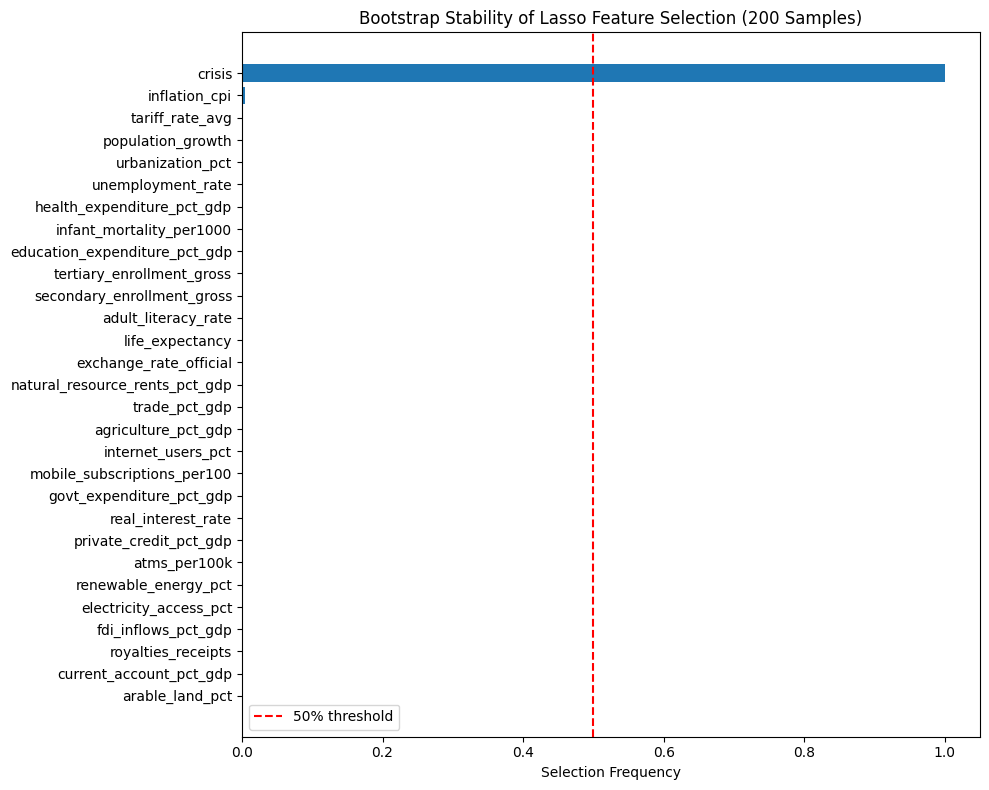

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

# ============================================================
# SETUP
# ============================================================

np.random.seed(42)  # ensures reproducibility of bootstrap sampling

X = X_train_scaled
y = y_train_cls

n_bootstraps = 200
n_samples, n_features = X.shape

# store which features are selected in each bootstrap
selection_matrix = np.zeros((n_bootstraps, n_features))

# ============================================================
# BOOTSTRAP LOOP
# ============================================================

for b in range(n_bootstraps):

    # ---- Step 1: draw bootstrap sample indices (WITH replacement)
    bootstrap_idx = np.random.choice(n_samples, size=n_samples, replace=True)

    X_boot = X[bootstrap_idx]
    y_boot = y[bootstrap_idx]

    # ---- Step 2: fit LassoCV with cross-validation on bootstrap sample
    lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso.fit(X_boot, y_boot)

    # ---- Step 3: record selected features (non-zero coefficients)
    selection_matrix[b, :] = (lasso.coef_ != 0)

# ============================================================
# SELECTION FREQUENCIES
# ============================================================

selection_freq = selection_matrix.mean(axis=0)

# assume you have feature names stored somewhere
feature_names = np.array(feature_names)  # ensure correct mapping

results = pd.DataFrame({
    "Feature": feature_names,
    "Selection Frequency": selection_freq
})

results = results.sort_values(by="Selection Frequency", ascending=True)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(results["Feature"], results["Selection Frequency"])

plt.axvline(0.5, color="red", linestyle="--", label="50% threshold")

plt.xlabel("Selection Frequency")
plt.title("Bootstrap Stability of Lasso Feature Selection (200 Samples)")
plt.legend()

plt.tight_layout()
plt.show()

Crisis is stable and the rest are unstable.

PRIME PROMPT:

Prep: Act as an expert Python Data Scientist. You are going to evaluate a binary crisi prediciton model on a country by country basis. The goal is to deterimine what threshold should be chosen for classifying a crisis risk.

Request: Write complete python code that Sweeps thresholds from 0.01 to 0.99. At each threshold, computes the total expected cost: FN × $50B + FP × $2M. Plots the expected cost curve as a function of τ.

Iterate: Identify and annotate the cost-minimizing threshold.


Mechanism Check: Add inline comments explaining exactly how everything is being done.

Evaluate: Provide a brief explanation of how I should interpert the results.


You already have the varaibles:
y_test_cls: true binary outcomes (0 = no crisis, 1 = crisis)
y_test_prob: predicted probabilities from the logistic regression model and know that False Negative (missed crisis) = $50,000,000,000 and
False Positive (false alarm) = $2,000,000

Optimal threshold (τ*): 0.12
Minimum expected cost: $0


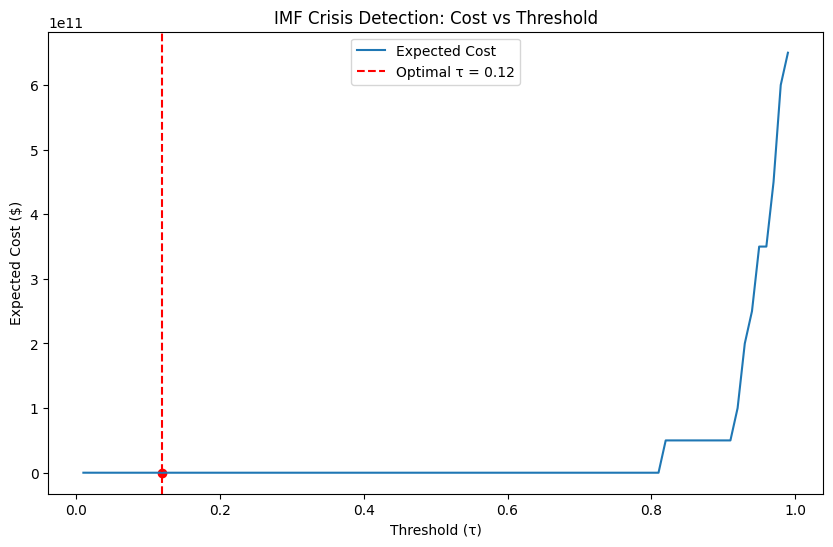

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# COST PARAMETERS (IMF operational context)
# ============================================================

COST_FN = 50_000_000_000   # $50B cost of missed crisis
COST_FP = 2_000_000        # $2M cost of false alarm

# ============================================================
# THRESHOLD GRID
# ============================================================

thresholds = np.arange(0.01, 1.00, 0.01)

costs = []

# ============================================================
# THRESHOLD SWEEP
# ============================================================

for tau in thresholds:

    # Convert probabilities into binary predictions
    y_pred = (y_test_prob >= tau).astype(int)

    # Compute confusion matrix components
    FN = np.sum((y_pred == 0) & (y_test_cls == 1))  # missed crises
    FP = np.sum((y_pred == 1) & (y_test_cls == 0))  # false alarms

    # Compute total expected cost
    total_cost = FN * COST_FN + FP * COST_FP

    costs.append(total_cost)

costs = np.array(costs)

# ============================================================
# FIND OPTIMAL THRESHOLD
# ============================================================

best_idx = np.argmin(costs)
best_tau = thresholds[best_idx]
best_cost = costs[best_idx]

print(f"Optimal threshold (τ*): {best_tau:.2f}")
print(f"Minimum expected cost: ${best_cost:,.0f}")

# ============================================================
# PLOT COST CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(thresholds, costs, label="Expected Cost")

plt.axvline(best_tau, linestyle="--", color="red",
            label=f"Optimal τ = {best_tau:.2f}")

plt.scatter(best_tau, best_cost, color="red")

plt.xlabel("Threshold (τ)")
plt.ylabel("Expected Cost ($)")
plt.title("IMF Crisis Detection: Cost vs Threshold")

plt.legend()
plt.show()

They show the same thing which is why I would continue to reccomend it.

